<a href="https://colab.research.google.com/github/iremozdemi/MLLM-VR-MA-TSP-Agent-Study/blob/main/Initial_Agent_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 from google.colab import drive
 drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

def plot_mtsp_routes(points, routes_dict, routes_plot_filename):
    """Plot the routes and points for the mTSP problem."""
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

    # Plot points and routes
    plt.figure(figsize=(8, 8))

    # Plot all points in red except the depot
    for idx, (x, y) in enumerate(points):
        if idx == 0:
            plt.plot(x, y, 'ks', markersize=10)  # Depot
        else:
            plt.plot(x, y, 'ro')
        plt.text(x, y, str(idx), fontsize=12, ha='right')

    # Plot routes
    for route in routes_dict.values():
        route_points = [points[node] for node in route]
        route_points = np.array(route_points)
        color = colors.pop(0) if colors else 'k'  # Default to black if out of colors
        plt.plot(route_points[:, 0], route_points[:, 1], marker='o', color=color, linestyle='-', linewidth=2, markersize=6)

    plt.savefig(routes_plot_filename, dpi=300, bbox_inches='tight', pad_inches=0.1)
    #plt.show()
    plt.close()

In [ ]:
def generate_prompt_vrp(num_salesmen, points, depot_index, demands=None, capacity=None):
    prompt = (
        f"Generate an approximate vehicle routing solution based on the following coordinates. "
        f"There will be {num_salesmen} salesmen, and each of them must start from depot {depot_index}, "
        f"visit a subset of customers, and return to the depot. "
        f"You do not need to apply mathematical optimization algorithms; instead, produce routes "
        f"based on logical reasoning. "
        f"Provide the routes in the following format: Salesman 1: 0 -> 3 -> 4 -> 7 -> 0. "
        f"Point coordinates: {points.tolist()}. "
    )

    if demands:
        prompt += f"Customer demands: {demands}. "

    if capacity:
        prompt += f"Vehicle capacity for each salesman: {capacity}. "

    prompt += (
        "Please generate a separate route for each salesman and ensure that all customers "
        "are visited exactly once by one of the salesmen."
    )

    return prompt


In [ ]:
def encode_image_data(points, depot_index=0):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(points[:, 0], points[:, 1], c='blue', label='Locations')
    ax.scatter(points[depot_index, 0], points[depot_index, 1], c='red', marker='o', s=100, label='Depot')
    for i, point in enumerate(points):
        ax.annotate(str(i), (point[0], point[1]), textcoords="offset points", xytext=(0,10), ha='center')
    ax.legend()

    img_buffer = io.BytesIO()
    plt.savefig(img_buffer, format='png')
    img_buffer.seek(0)
    base64_image = base64.b64encode(img_buffer.read()).decode('utf-8')
    return base64_image


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


--- BAŞLANGIÇ ÇÖZÜMÜ İŞLEMİ BAŞLATILIYOR (ÖKLİD Mesafesi Odaklı) ---
✅ JSON dosyasından 22 şehir koordinatı başarıyla okundu.
🔄 DEPO NOKTASI (Index 0) zorla (150, 180) olarak ayarlandı.
⏱️ Adım 1 (Veri Yükleme ve Depo): 0.8702 saniye
⏱️ Adım 2a (Geçici Görsel Oluşturma): 0.3821 saniye

🤖 Gemini API çağrılıyor... İLK optimal rota **ÖKLİD mesafesine göre** tahmin ediliyor.
✅ Gemini yanıtı alındı.
⏱️ Adım 2b (Gemini API Çağrısı): 111.5115 saniye
⏱️ Adım 2 (Toplam Görsel & API): 111.8936 saniye

🧠 Gemini Optimal Rota Sırası: [0, 17, 20, 12, 14, 16, 21, 8, 3, 4, 11, 13, 19, 18, 15, 5, 7, 9, 2, 1, 6, 10, 0]
📏 Hesaplanan Toplam İlk Mesafe (Öklid): 461.41
⏱️ Adım 3 (Mesafe Hesaplama): 0.0004 saniye


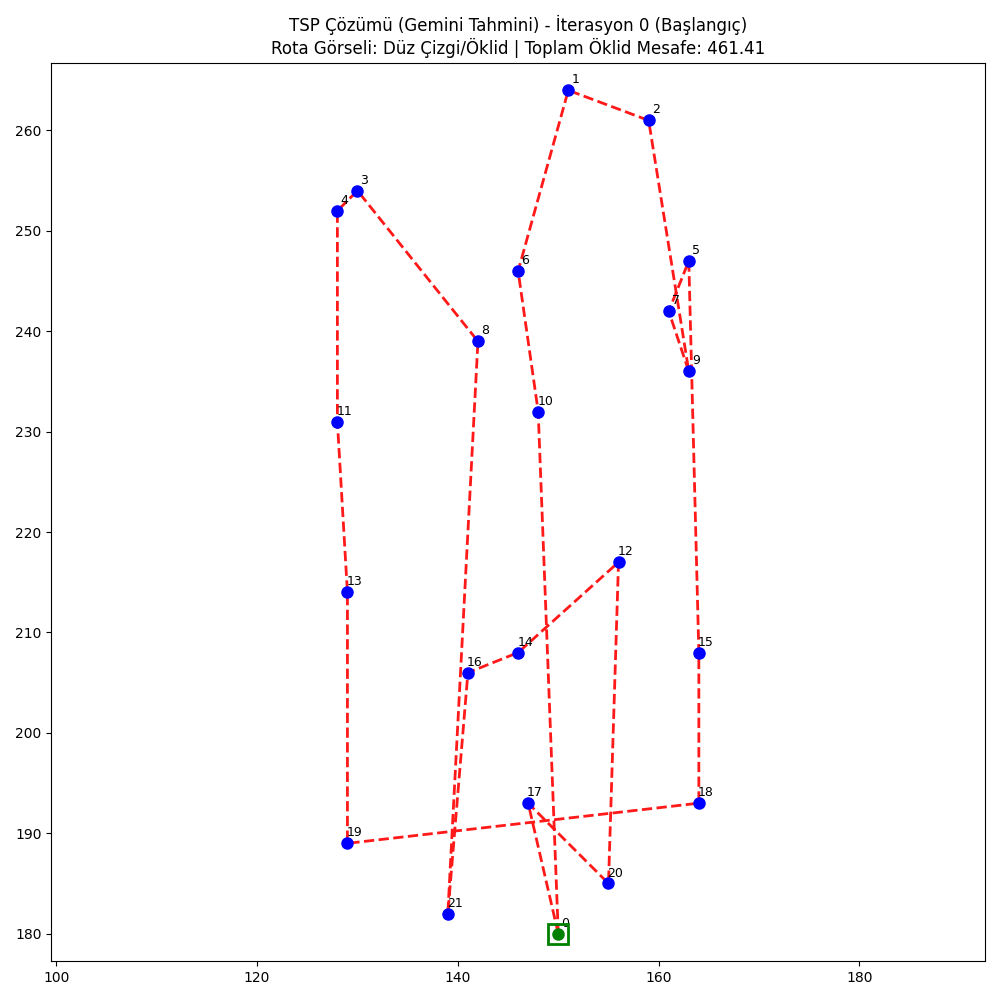


✅ ROTA GÖRSELİ KAYDEDİLDİ VE EKRANDA GÖSTERİLDİ: /content/drive/MyDrive/13nokta/png_outputs/tsp_gemini_optimal_solution_euclidean_depot_0_initial.png
⏱️ Adım 4 (Rota Görselleştirme): 0.7884 saniye

🚀 BAŞLANGIÇ ÇÖZÜMÜ KAYDEDİLDİ: /content/drive/MyDrive/13nokta/json_outputs/initial_route_output.json
-> Rota görseli dosya yolu JSON'a eklendi: /content/drive/MyDrive/13nokta/png_outputs/tsp_gemini_optimal_solution_euclidean_depot_0_initial.png
-> İkinci script bu dosyayı okuyarak iyileştirmeye başlayacaktır.
⏱️ Adım 5 (JSON Kaydetme): 0.2923 saniye

--- İŞLEM TAMAMLANDI - TOPLAM SÜRE: 113.8459 saniye ---


In [ ]:
# tsp_initial_solver.py - INITIAL SOLUTION AND SAVING ROUTE VISUALIZATION AS PNG

import matplotlib.pyplot as plt
import json
import numpy as np
import os
import io
import base64
import re
import google.generativeai as genai
import time  # Added for CPU time measurement
from IPython.display import display, Image

# =================================================================
# --- API CONFIGURATION AND CONSTANTS ---
# =================================================================

try:
    genai.configure(api_key="YOUR_API_KEY_HERE")
except Exception as e:
    print(f"Error: Gemini API key could not be configured. Please check your settings. Error: {e}")

# --- File Paths ---
json_filename = "/content/drive/MyDrive/13nodes/json_outputs/eil22_points.json"
output_plot_filename = "/content/drive/MyDrive/13nodes/png_outputs/tsp_gemini_optimal_solution_euclidean_depot_0_initial.png"
initial_output_json = "/content/drive/MyDrive/13nodes/json_outputs/initial_route_output.json"
depot_index = 0

# =================================================================
# --- FUNCTIONS ---
# =================================================================

def calculate_total_euclidean_distance(cities, route_list):
    """Calculates the total Euclidean (straight-line) distance for the given route."""
    total_distance = 0.0
    if not route_list or len(route_list) < 2:
        return float('inf')

    temp_route_list = list(route_list)
    if temp_route_list[0] != temp_route_list[-1]:
        temp_route_list.append(temp_route_list[0])

    route_coords = cities[temp_route_list]

    for i in range(len(route_coords) - 1):
        p1 = route_coords[i]
        p2 = route_coords[i+1]
        segment_distance = np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
        total_distance += segment_distance

    return total_distance


def generate_and_encode_image(points, depot_index=0):
    """Generates a temporary image from coordinates and returns it in base64 format."""
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(points[:, 0], points[:, 1], c='blue', s=50, zorder=2)
    ax.scatter(points[depot_index, 0], points[depot_index, 1],
               c='red', marker='o', s=150, zorder=3, label='Depot (0)')

    for i, point in enumerate(points):
        ax.annotate(str(i), (point[0], point[1]),
                    textcoords="offset points", xytext=(5, 5),
                    ha='center', fontsize=9)

    ax.set_title(
        f"Temporary TSP Visualization for Gemini (Depot: "
        f"{points[depot_index, 0]:.0f}, {points[depot_index, 1]:.0f})"
    )
    ax.axis('off')
    ax.margins(0.1)

    img_buffer = io.BytesIO()
    plt.savefig(img_buffer, format='png', bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)
    img_buffer.seek(0)

    return base64.b64encode(img_buffer.read()).decode('utf-8')


def get_gemini_optimal_route(base64_image, cities):
    """Calls Gemini API to obtain an initial TSP route."""

    prompt = f"""
    Using the {len(cities)} cities (points) shown in the image, find a possible shortest route
    for the Traveling Salesman Problem (TSP).
    The depot node (index 0) is located at
    ({cities[depot_index, 0]:.0f}, {cities[depot_index, 1]:.0f}).
    The route must minimize the total distance based on EUCLIDEAN (straight-line) distance.
    Return only the city index sequence (starting from 0 and ending at 0) as a Python list.
    THE RESPONSE MUST CONTAIN ONLY A PYTHON LIST.
    No explanations, no additional text.
    The route must visit all cities exactly once and return to the depot.
    Example: [0, 3, 1, 2, 0]
    """

    print("\n🤖 Calling Gemini API... Estimating initial optimal route based on Euclidean distance.")

    try:
        model = genai.GenerativeModel("gemini-2.5-flash")
        response = model.generate_content(
            [{"mime_type": "image/png", "data": base64_image}, prompt]
        )

        route_text = response.text.strip()
        print("✅ Gemini response received.")

        match = re.search(r"\[.*?\]", route_text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group(0))
            except json.JSONDecodeError:
                print(f"WARNING: Initial response could not be parsed as JSON. Raw text: {match.group(0)}")
                return None
        return None

    except Exception as e:
        print(f"ERROR: Gemini API call failed. Error: {e}")
        return None


def visualize_route(cities, route_list, distance, iteration_info, filename, depot_index):
    """Draws, saves, and displays the final route using Euclidean connections."""
    try:
        fig, ax = plt.subplots(figsize=(10, 10))

        temp_route_list = list(route_list)
        if temp_route_list[0] != temp_route_list[-1]:
            temp_route_list.append(temp_route_list[0])

        route_coords = cities[temp_route_list]

        route_x = route_coords[:, 0]
        route_y = route_coords[:, 1]

        ax.plot(route_x, route_y, 'r--', linewidth=2,
                alpha=0.9, zorder=1, label='Euclidean Route')

        for i, (x, y) in enumerate(cities):
            color = 'blue' if i != depot_index else 'green'
            ax.plot(x, y, 'o', color=color, markersize=8, zorder=2)
            ax.annotate(str(i), (x, y),
                        textcoords="offset points", xytext=(5, 5),
                        ha='center', fontsize=9)

        ax.plot(cities[depot_index, 0],
                cities[depot_index, 1],
                's', color='green', markersize=15,
                fillstyle='none', markeredgewidth=2, zorder=4)

        title = (
            f"TSP Solution (Gemini Estimation) - {iteration_info}\n"
            f"Route Visualization: Straight-Line/Euclidean | "
            f"Total Euclidean Distance: {distance:.2f}"
        )

        ax.set_title(title, fontsize=12)
        ax.axis('equal')
        plt.tight_layout()

        os.makedirs(os.path.dirname(filename), exist_ok=True)
        plt.savefig(filename)

        display(Image(filename=filename))
        plt.close(fig)

        print(f"\n✅ ROUTE VISUALIZATION SAVED AND DISPLAYED: {filename}")

    except Exception as e:
        print(f"ERROR: Final visualization failed. Error: {e}")


# =================================================================
# --- MAIN FLOW: INITIAL SOLUTION ---
# =================================================================

total_start_time = time.time()
print("--- INITIAL SOLUTION PROCESS STARTED (Euclidean Distance Based) ---")

# 1. Load Data and Update Depot
step_start_time = time.time()

try:
    with open(json_filename, 'r') as f:
        coordinates_raw = json.load(f)

    cities = np.array(coordinates_raw, dtype=float)
    new_depot_coords = np.array([150.0, 180.0], dtype=float)

    if cities.shape[0] > depot_index:
        cities[depot_index] = new_depot_coords

    print(f"✅ {len(cities)} city coordinates successfully loaded from JSON.")
    print(f"🔄 DEPOT NODE (Index {depot_index}) forced to "
          f"({new_depot_coords[0]:.0f}, {new_depot_coords[1]:.0f}).")

except Exception as e:
    print(f"ERROR: Data loading/processing failed: {e}")
    exit()

step_end_time = time.time()
print(f"⏱ Step 1 (Data Loading & Depot Update): {step_end_time - step_start_time:.4f} seconds")


# 2. Generate Image and Call Gemini
step_start_time = time.time()

base64_image = generate_and_encode_image(cities, depot_index)

step_mid_time = time.time()
print(f"⏱ Step 2a (Temporary Image Generation): {step_mid_time - step_start_time:.4f} seconds")

route_list = get_gemini_optimal_route(base64_image, cities)

if not route_list or not isinstance(route_list, list) or not all(isinstance(x, int) for x in route_list):
    print("ERROR: A valid route list was not received from Gemini. Process terminated.")
    exit()

step_end_time = time.time()
print(f"⏱ Step 2b (Gemini API Call): {step_end_time - step_mid_time:.4f} seconds")
print(f"⏱ Step 2 (Total Image & API): {step_end_time - step_start_time:.4f} seconds")


# 3. Compute Distance
step_start_time = time.time()

total_euclidean_distance = calculate_total_euclidean_distance(cities, route_list)

print(f"\n🧠 Gemini Estimated Optimal Route: {route_list}")
print(f"📏 Computed Total Initial Distance (Euclidean): {total_euclidean_distance:.2f}")

step_end_time = time.time()
print(f"⏱ Step 3 (Distance Calculation): {step_end_time - step_start_time:.4f} seconds")


# 4. Visualize and Save Route
step_start_time = time.time()

visualize_route(
    cities,
    route_list,
    total_euclidean_distance,
    "Iteration 0 (Initial)",
    output_plot_filename,
    depot_index
)

step_end_time = time.time()
print(f"⏱ Step 4 (Route Visualization): {step_end_time - step_start_time:.4f} seconds")


# 5. Save Output as JSON (Input for Second Script)
step_start_time = time.time()

output_data = {
    "cities_coordinates": cities.tolist(),
    "initial_route": route_list,
    "initial_distance_EUCLIDEAN": total_euclidean_distance,
    "depot_index": depot_index,
    "current_image_path": output_plot_filename
}

try:
    os.makedirs(os.path.dirname(initial_output_json), exist_ok=True)
    with open(initial_output_json, 'w') as f:
        json.dump(output_data, f, indent=4)

    print(f"\n🚀 INITIAL SOLUTION SAVED: {initial_output_json}")
    print(f"-> Route image path added to JSON: {output_plot_filename}")
    print("-> The second script will read this file and start improvement.")

except Exception as e:
    print(f"ERROR: Failed to save initial solution. Error: {e}")

step_end_time = time.time()
print(f"⏱ Step 5 (JSON Save): {step_end_time - step_start_time:.4f} seconds")


total_end_time = time.time()
print(f"\n--- PROCESS COMPLETED - TOTAL TIME: {total_end_time - total_start_time:.4f} seconds ---")